In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
dataset_path = './Dataset/carv3.csv'

car_raw = pd.read_csv(dataset_path)

In [4]:
car_raw.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
car_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [6]:
car_raw.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'selling_price'}>],
       [<Axes: title={'center': 'km_driven'}>,
        <Axes: title={'center': 'seats'}>]], dtype=object)

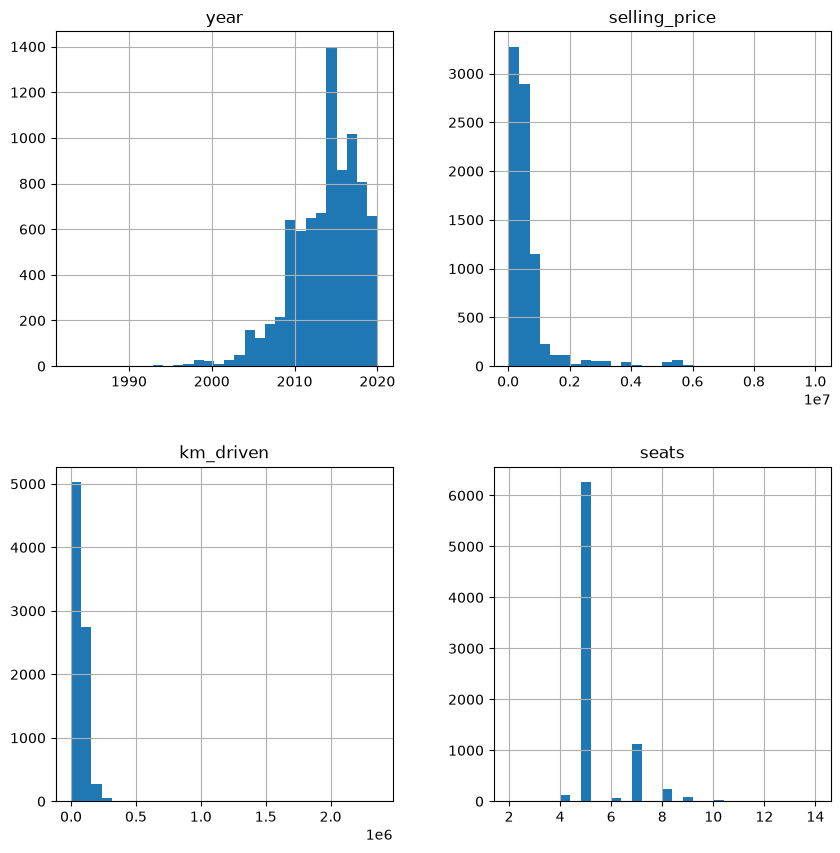

In [7]:
car_raw.hist(bins=30, figsize=(10,10))

In [8]:
from sklearn.model_selection import train_test_split

car_train, car_test = train_test_split(car_raw, test_size=0.2,
                                    random_state=42)

In [9]:
car_df = car_train
car_test.head()
#car_raw['Location'].value_counts()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1971,Honda City 1.5 GXI,2004,198000,110000,Petrol,Individual,Manual,Third Owner,12.8 kmpl,1493 CC,100 bhp,13.1kgm@ 4600rpm,5.0
4664,Tata Safari Storme EX,2014,500000,291977,Diesel,Individual,Manual,First Owner,14.0 kmpl,2179 CC,138.1 bhp,320Nm@ 1700-2700rpm,7.0
5448,Maruti Ritz VDi,2016,425000,70000,Diesel,Individual,Manual,First Owner,23.2 kmpl,1248 CC,73.94 bhp,190Nm@ 2000rpm,5.0
3333,Honda City 2017-2020 VTEC,2006,150000,120000,Petrol,Individual,Manual,Second Owner,16.9 kmpl,1497 CC,100 bhp,"13.5@ 4,800(kgm@ rpm)",5.0
2316,Maruti Swift VDI,2013,525000,69000,Diesel,Individual,Manual,Second Owner,22.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0


Mapping owners

In [10]:
car_df['owner'].unique()

<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str

In [11]:
owner_mapping = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
}

car_df['owner'] = car_df['owner'].map(owner_mapping)

car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
6518,Tata Tiago NRG Petrol AMT,2019,520000,2560,Petrol,Individual,Automatic,1,24.0 kmpl,1199 CC,83.81 bhp,114Nm@ 3500rpm,5.0
6144,Honda Brio S MT,2013,300000,80000,Petrol,Individual,Manual,2,19.4 kmpl,1198 CC,86.8 bhp,109Nm@ 4500rpm,5.0
6381,Hyundai i20 1.4 CRDi Asta,2011,380000,150000,Diesel,Individual,Manual,4,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
438,Maruti Swift Dzire VDI,2013,530000,120000,Diesel,Individual,Manual,2,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
5939,Maruti Alto K10 VXI,2017,335000,25000,Petrol,Individual,Manual,1,23.95 kmpl,998 CC,67.05 bhp,90Nm@ 3500rpm,5.0


In [12]:
car_df.info()

<class 'pandas.DataFrame'>
Index: 6502 entries, 6518 to 7270
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6502 non-null   str    
 1   year           6502 non-null   int64  
 2   selling_price  6502 non-null   int64  
 3   km_driven      6502 non-null   int64  
 4   fuel           6502 non-null   str    
 5   seller_type    6502 non-null   str    
 6   transmission   6502 non-null   str    
 7   owner          6502 non-null   int64  
 8   mileage        6332 non-null   str    
 9   engine         6332 non-null   str    
 10  max_power      6336 non-null   str    
 11  torque         6331 non-null   str    
 12  seats          6332 non-null   float64
dtypes: float64(1), int64(4), str(8)
memory usage: 711.2 KB


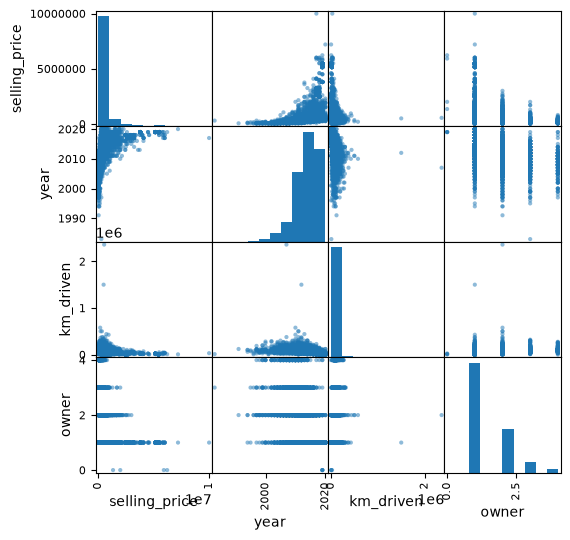

In [13]:
from pandas.plotting import scatter_matrix

attributes = ['selling_price', 'year', 'km_driven', 'owner']
scatter_matrix(car_df[attributes], figsize=(6,6))
plt.show()

/var/folders/0m/3xxy2n5n18z_d7z8xq162ykw0000gn/T/ipykernel_26997/1816806017.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='owner', y='selling_price', data=car_df, palette='coolwarm')


<Axes: xlabel='owner', ylabel='selling_price'>

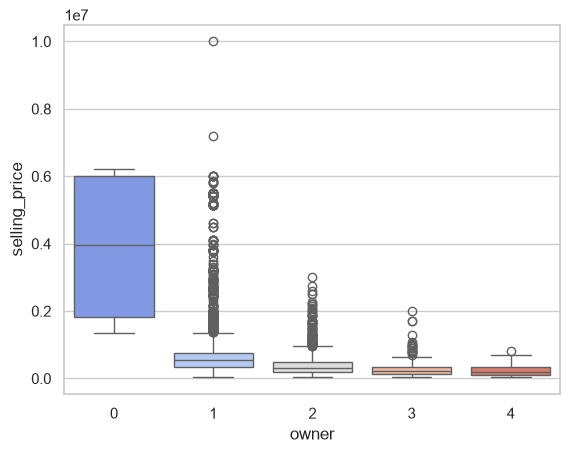

In [14]:
sns.set_theme(style="whitegrid")
sns.boxplot(x='owner', y='selling_price', data=car_df, palette='coolwarm')

In [15]:
#removed 3 top abnormally km_driven car
max_km_index = car_df['km_driven'].idxmax()
car_df = car_df.drop(index=max_km_index)

<Axes: xlabel='km_driven', ylabel='selling_price'>

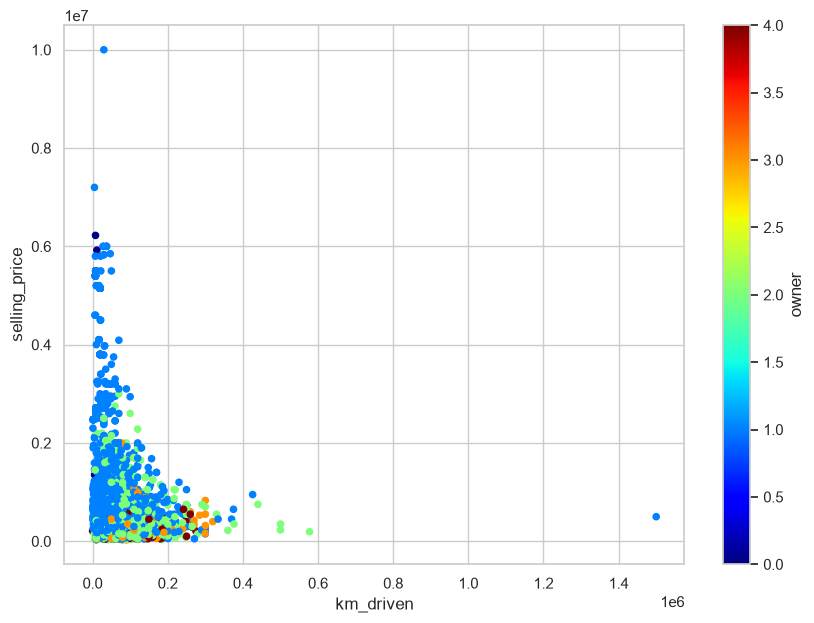

In [16]:
car_df.plot(kind="scatter", x="km_driven", y="selling_price", grid=True,
            c="owner", cmap="jet", colorbar=True,
            legend=True, sharex=False, figsize=(10, 7))

In [17]:
car_df[["mileage_value", "mileage_unit"]] = car_df["mileage"].str.extract(
    r"(\d+\.\d+|\d+)\s*(.*)"
)

car_df["mileage_value"] = car_df["mileage_value"].astype(float)

car_df["mileage_unit"] = (
    car_df["mileage_unit"].str.replace("/", "").str.strip().str.lower()
)


In [18]:
car_df['max_power'] = car_df['max_power'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [19]:
car_df['engine'] = car_df['engine'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [20]:
car_df.info()

<class 'pandas.DataFrame'>
Index: 6501 entries, 6518 to 7270
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6501 non-null   str    
 1   year           6501 non-null   int64  
 2   selling_price  6501 non-null   int64  
 3   km_driven      6501 non-null   int64  
 4   fuel           6501 non-null   str    
 5   seller_type    6501 non-null   str    
 6   transmission   6501 non-null   str    
 7   owner          6501 non-null   int64  
 8   mileage        6331 non-null   str    
 9   engine         6331 non-null   float64
 10  max_power      6334 non-null   float64
 11  torque         6330 non-null   str    
 12  seats          6331 non-null   float64
 13  mileage_value  6331 non-null   float64
 14  mileage_unit   6331 non-null   str    
dtypes: float64(4), int64(4), str(7)
memory usage: 812.6 KB


<Axes: xlabel='km_driven', ylabel='selling_price'>

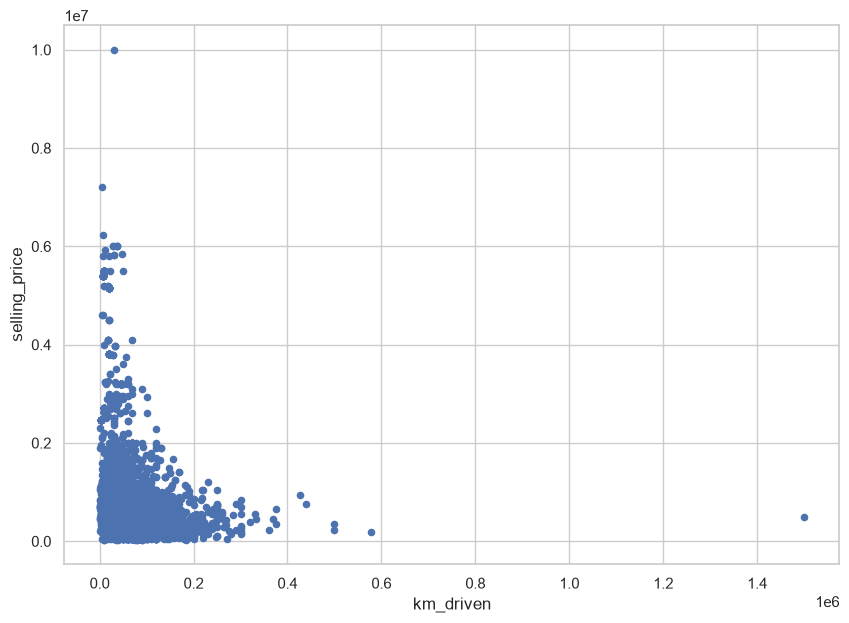

In [21]:
car_df.plot(kind="scatter", x="km_driven", y="selling_price", grid=True,
            legend=True, sharex=False, figsize=(10, 7))
# car_df.hist(['Fuel Tank Capacity'], bins=50)

In [22]:
#handeling null data
null_mask = car_df.isnull().any(axis=1)
df_nulls = car_df[null_mask].copy()
car_df.dropna(inplace=True)

In [23]:
car_df.drop(columns=['torque'], inplace=True)

car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,mileage_value,mileage_unit
6518,Tata Tiago NRG Petrol AMT,2019,520000,2560,Petrol,Individual,Automatic,1,24.0 kmpl,1199.0,83.81,5.0,24.00,kmpl
6144,Honda Brio S MT,2013,300000,80000,Petrol,Individual,Manual,2,19.4 kmpl,1198.0,86.80,5.0,19.40,kmpl
6381,Hyundai i20 1.4 CRDi Asta,2011,380000,150000,Diesel,Individual,Manual,4,23.0 kmpl,1396.0,90.00,5.0,23.00,kmpl
438,Maruti Swift Dzire VDI,2013,530000,120000,Diesel,Individual,Manual,2,23.4 kmpl,1248.0,74.00,5.0,23.40,kmpl
5939,Maruti Alto K10 VXI,2017,335000,25000,Petrol,Individual,Manual,1,23.95 kmpl,998.0,67.05,5.0,23.95,kmpl


In [24]:
car_df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
mileage_value    0
mileage_unit     0
dtype: int64

In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

car_num = car_df.select_dtypes(include=[np.number])

numeric_cols = ['engine', 'max_power', 'seats', 'mileage_value']

imputer = SimpleImputer(strategy='median')

car_df[numeric_cols] = imputer.fit_transform(car_df[numeric_cols])



In [26]:
car_cng = car_df[car_df['mileage_unit'] == 'kmkg']
car_cng.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,mileage_value,mileage_unit
5198,Maruti Eeco CNG HTR 5-STR,2014,300000,90000,CNG,Individual,Manual,1,21.94 km/kg,1196.0,63.00,5.0,21.94,kmkg
5532,Hyundai Accent Executive CNG,2012,275000,48000,CNG,Individual,Manual,1,13.2 km/kg,1495.0,93.70,5.0,13.20,kmkg
4545,Hyundai i10 Magna LPG,2012,300000,60000,LPG,Individual,Manual,1,19.2 km/kg,1086.0,68.05,5.0,19.20,kmkg
5185,Maruti Zen Estilo LXI Green (CNG),2014,235000,70000,CNG,Individual,Manual,2,26.3 km/kg,998.0,67.10,5.0,26.30,kmkg
5199,Maruti Eeco CNG HTR 5-STR,2017,390000,30000,CNG,Individual,Manual,1,21.94 km/kg,1196.0,63.00,5.0,21.94,kmkg


In [ ]:
car_df = car_df[car_df['mileage_unit'] == 'kmpl']

In [28]:
corr_matrix = car_df.corr(numeric_only=True)
corr_matrix["selling_price"].sort_values(ascending=False)

selling_price    1.000000
max_power        0.748859
engine           0.449684
year             0.413995
seats            0.038273
mileage_value   -0.127806
owner           -0.236348
km_driven       -0.243576
Name: selling_price, dtype: float64

In [29]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,mileage_value,mileage_unit
6518,Tata Tiago NRG Petrol AMT,2019,520000,2560,Petrol,Individual,Automatic,1,24.0 kmpl,1199.0,83.81,5.0,24.00,kmpl
6144,Honda Brio S MT,2013,300000,80000,Petrol,Individual,Manual,2,19.4 kmpl,1198.0,86.80,5.0,19.40,kmpl
6381,Hyundai i20 1.4 CRDi Asta,2011,380000,150000,Diesel,Individual,Manual,4,23.0 kmpl,1396.0,90.00,5.0,23.00,kmpl
438,Maruti Swift Dzire VDI,2013,530000,120000,Diesel,Individual,Manual,2,23.4 kmpl,1248.0,74.00,5.0,23.40,kmpl
5939,Maruti Alto K10 VXI,2017,335000,25000,Petrol,Individual,Manual,1,23.95 kmpl,998.0,67.05,5.0,23.95,kmpl


In [52]:
car_df.drop(columns=['mileage'], inplace=True)
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,engine,max_power,seats,mileage_value,mileage_unit
6518,Tata Tiago NRG Petrol AMT,2019,520000,2560,Petrol,Individual,Automatic,1,1199.0,83.81,5.0,24.00,kmpl
6144,Honda Brio S MT,2013,300000,80000,Petrol,Individual,Manual,2,1198.0,86.80,5.0,19.40,kmpl
6381,Hyundai i20 1.4 CRDi Asta,2011,380000,150000,Diesel,Individual,Manual,4,1396.0,90.00,5.0,23.00,kmpl
438,Maruti Swift Dzire VDI,2013,530000,120000,Diesel,Individual,Manual,2,1248.0,74.00,5.0,23.40,kmpl
5939,Maruti Alto K10 VXI,2017,335000,25000,Petrol,Individual,Manual,1,998.0,67.05,5.0,23.95,kmpl


In [62]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X = car_df.drop('selling_price', axis=1)
y = car_df['selling_price']

categorical_cols = ['fuel', 'seller_type', 'transmission']
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_processed = transformer.fit_transform(X)
new_columns = transformer.get_feature_names_out()
X_final = pd.DataFrame(X_processed, columns=new_columns, index=X.index)
X_final.head()

,year,km_driven,owner,engine,max_power,seats,mileage_value,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,name,mileage_unit
6518,1.293194,-1.299831,-0.625407,-0.527629,-0.228403,-0.437065,1.1582,1.0,1.0,0.0,0.0,Tata Tiago NRG Petrol AMT,kmpl
6144,-0.25168,0.213764,0.793089,-0.529611,-0.144841,-0.437065,0.004717,1.0,1.0,0.0,1.0,Honda Brio S MT,kmpl
6381,-0.766637,1.58194,3.63008,-0.137035,-0.055409,-0.437065,0.907443,0.0,1.0,0.0,1.0,Hyundai i20 1.4 CRDi Asta,kmpl
438,-0.25168,0.995579,0.793089,-0.430476,-0.502567,-0.437065,1.007746,0.0,1.0,0.0,1.0,Maruti Swift Dzire VDI,kmpl
5939,0.778236,-0.861232,-0.625407,-0.926153,-0.6968,-0.437065,1.145662,1.0,1.0,0.0,1.0,Maruti Alto K10 VXI,kmpl


Till now all data types have been simplified and scaled